# Practice: 
1. Run this notebook
2. Optimize the training process and try to improve the model performance base on your understanding of the give code, dataset and model architecture
3. Observe the the effect of different hyperparameters

# RoboCop AI: Crime Detector DNN
Imagine a futuristic city run by AI. The government deploys a Robot Police Cop (powered by a Deep Neural Network) to predict whether a person will commit a crime. But… the robot starts failing — it overfits to past crime data and can’t generalize to new situations. Now we retrain it with regularization to make it smarter and fairer.
![robo](robo.png)


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [ ]:
from google.colab import files

uploaded = files.upload()

In [3]:
import re

with open("communities.names", "r") as file:
    lines = file.readlines()

# Extract column names from @attribute lines
columns = []
for line in lines:
    match = re.match(r'@attribute\s+([^\s]+)\s+', line.strip(), re.IGNORECASE)
    if match:
        columns.append(match.group(1))

print("Total columns extracted:", len(columns))  # Should be 128
print(columns[:5], "...", columns[-5:])  # Preview first/last columns


Total columns extracted: 128
['state', 'county', 'community', 'communityname', 'fold'] ... ['LemasPctPolicOnPatr', 'LemasGangUnitDeploy', 'LemasPctOfficDrugUn', 'PolicBudgPerPop', 'ViolentCrimesPerPop']


In [4]:
df = pd.read_csv('communities.data', header=None, names=columns, na_values='?')

In [5]:
df

,state,county,community,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,...,LandArea,PopDens,PctUsePubTrans,PolicCars,PolicOperBudg,LemasPctPolicOnPatr,LemasGangUnitDeploy,LemasPctOfficDrugUn,PolicBudgPerPop,ViolentCrimesPerPop
0,8,NaN,NaN,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,...,0.12,0.26,0.20,0.06,0.04,0.90,0.5,0.32,0.14,0.20
1,53,NaN,NaN,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,...,0.02,0.12,0.45,NaN,NaN,NaN,NaN,0.00,NaN,0.67
2,24,NaN,NaN,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,...,0.01,0.21,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.43
3,34,5.0,81440.0,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,...,0.02,0.39,0.28,NaN,NaN,NaN,NaN,0.00,NaN,0.12
4,42,95.0,6096.0,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,...,0.04,0.09,0.02,NaN,NaN,NaN,NaN,0.00,NaN,0.03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,12,NaN,NaN,TempleTerracecity,10,0.01,0.40,0.10,0.87,0.12,...,0.01,0.28,0.05,NaN,NaN,NaN,NaN,0.00,NaN,0.09
1990,6,NaN,NaN,Seasidecity,10,0.05,0.96,0.46,0.28,0.83,...,0.02,0.37,0.20,NaN,NaN,NaN,NaN,0.00,NaN,0.45
1991,9,9.0,80070.0,Waterburytown,10,0.16,0.37,0.25,0.69,0.04,...,0.08,0.32,0.18,0.08,0.06,0.78,0.0,0.91,0.28,0.23
1992,25,17.0,72600.0,Walthamcity,10,0.08,0.51,0.06,0.87,0.22,...,0.03,0.38,0.33,0.02,0.02,0.79,0.0,0.22,0.18,0.19


In [6]:
df['ViolentCrimesPerPop']

0       0.20
1       0.67
2       0.43
3       0.12
4       0.03
        ... 
1989    0.09
1990    0.45
1991    0.23
1992    0.19
1993    0.48
Name: ViolentCrimesPerPop, Length: 1994, dtype: float64

In [7]:
df.dropna(axis=1, thresh=len(df)*0.8, inplace=True)
df.dropna(inplace=True)
df['CrimeBinary'] = (df['ViolentCrimesPerPop'] > 0.15).astype(int)

C:\Users\Asim Shah\AppData\Local\Temp\ipykernel_4596\1329859761.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['CrimeBinary'] = (df['ViolentCrimesPerPop'] > 0.15).astype(int)


In [8]:
print(df.shape)
df.isnull().sum().sum()

(1993, 105)


np.int64(0)

In [9]:
df['CrimeBinary'].value_counts()

CrimeBinary
0    1001
1     992
Name: count, dtype: int64

In [10]:
# df.columns.to_list()

In [11]:
df

,state,communityname,fold,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,...,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn,ViolentCrimesPerPop,CrimeBinary
0,8,Lakewoodcity,1,0.19,0.33,0.02,0.90,0.12,0.17,0.34,...,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32,0.20,1
1,53,Tukwilacity,1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,...,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00,0.67,1
2,24,Aberdeentown,1,0.00,0.42,0.49,0.56,0.17,0.04,0.39,...,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00,0.43,1
3,34,Willingborotownship,1,0.04,0.77,1.00,0.08,0.12,0.10,0.51,...,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00,0.12,0
4,42,Bethlehemtownship,1,0.01,0.55,0.02,0.95,0.09,0.05,0.38,...,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00,0.03,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,12,TempleTerracecity,10,0.01,0.40,0.10,0.87,0.12,0.16,0.43,...,0.28,0.34,0.48,0.39,0.01,0.28,0.05,0.00,0.09,0
1990,6,Seasidecity,10,0.05,0.96,0.46,0.28,0.83,0.32,0.69,...,0.25,0.17,0.10,0.00,0.02,0.37,0.20,0.00,0.45,1
1991,9,Waterburytown,10,0.16,0.37,0.25,0.69,0.04,0.25,0.35,...,0.68,0.61,0.79,0.76,0.08,0.32,0.18,0.91,0.23,1
1992,25,Walthamcity,10,0.08,0.51,0.06,0.87,0.22,0.10,0.58,...,0.64,0.54,0.59,0.52,0.03,0.38,0.33,0.22,0.19,1


In [12]:
# Drop non-numeric columns first (like 'state', 'communityname')
X = df.drop(columns=['state', 'communityname', 'fold', 'ViolentCrimesPerPop', 'CrimeBinary'])
#y_reg = df['ViolentCrimesPerPop']
y_clf = df['CrimeBinary']

In [13]:
X

,population,householdsize,racepctblack,racePctWhite,racePctAsian,racePctHisp,agePct12t21,agePct12t29,agePct16t24,agePct65up,...,NumStreet,PctForeignBorn,PctBornSameState,PctSameHouse85,PctSameCity85,PctSameState85,LandArea,PopDens,PctUsePubTrans,LemasPctOfficDrugUn
0,0.19,0.33,0.02,0.90,0.12,0.17,0.34,0.47,0.29,0.32,...,0.00,0.12,0.42,0.50,0.51,0.64,0.12,0.26,0.20,0.32
1,0.00,0.16,0.12,0.74,0.45,0.07,0.26,0.59,0.35,0.27,...,0.00,0.21,0.50,0.34,0.60,0.52,0.02,0.12,0.45,0.00
2,0.00,0.42,0.49,0.56,0.17,0.04,0.39,0.47,0.28,0.32,...,0.00,0.14,0.49,0.54,0.67,0.56,0.01,0.21,0.02,0.00
3,0.04,0.77,1.00,0.08,0.12,0.10,0.51,0.50,0.34,0.21,...,0.00,0.19,0.30,0.73,0.64,0.65,0.02,0.39,0.28,0.00
4,0.01,0.55,0.02,0.95,0.09,0.05,0.38,0.38,0.23,0.36,...,0.00,0.11,0.72,0.64,0.61,0.53,0.04,0.09,0.02,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1989,0.01,0.40,0.10,0.87,0.12,0.16,0.43,0.51,0.35,0.30,...,0.00,0.22,0.28,0.34,0.48,0.39,0.01,0.28,0.05,0.00
1990,0.05,0.96,0.46,0.28,0.83,0.32,0.69,0.86,0.73,0.14,...,0.00,0.53,0.25,0.17,0.10,0.00,0.02,0.37,0.20,0.00
1991,0.16,0.37,0.25,0.69,0.04,0.25,0.35,0.50,0.31,0.54,...,0.02,0.25,0.68,0.61,0.79,0.76,0.08,0.32,0.18,0.91
1992,0.08,0.51,0.06,0.87,0.22,0.10,0.58,0.74,0.63,0.41,...,0.01,0.45,0.64,0.54,0.59,0.52,0.03,0.38,0.33,0.22


In [14]:
X.shape

(1993, 100)

In [15]:
X.isnull().sum().sum()

np.int64(0)

In [16]:
# Splitting

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)


In [18]:
X_train.shape

(1395, 100)

In [19]:
y_train.shape

(1395,)

In [20]:
X_temp.shape

(598, 100)

In [21]:
y_temp

484     0
800     0
1235    1
1380    1
316     1
       ..
1075    0
305     1
1182    1
908     0
1419    0
Name: CrimeBinary, Length: 598, dtype: int64

In [22]:
X_val.shape

(299, 100)

In [23]:
y_val.shape

(299,)

In [24]:
X_test.shape

(299, 100)

In [25]:
# Scalling

In [26]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

In [27]:
# Convert to pytorch tensors

In [28]:
# -------- FEATURES --------
X_train = torch.from_numpy(np.asarray(X_train)).float()
X_val   = torch.from_numpy(np.asarray(X_val)).float()
X_test  = torch.from_numpy(np.asarray(X_test)).float()

# -------- LABELS --------
y_train = torch.from_numpy(np.asarray(y_train)).long()
y_val   = torch.from_numpy(np.asarray(y_val)).long()
y_test  = torch.from_numpy(np.asarray(y_test)).long()


C:\Users\Asim Shah\AppData\Local\Temp\ipykernel_4596\896947424.py:7: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train = torch.from_numpy(np.asarray(y_train)).long()


In [29]:
from torch.utils.data import DataLoader, TensorDataset
train_dataset = TensorDataset(X_train, y_train)
val_dataset   = TensorDataset(X_val, y_val)
test_dataset  = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [30]:
class ClassifierNet(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.fc1 = nn.Linear(input_dim, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.fc3(x)
        return x


In [55]:
def train_model(model, optimizer, scheduler=None, epochs=50):
    criterion = nn.CrossEntropyLoss()
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_loss = float("inf")
    patience = 100
    counter = 0
    best_state = model.state_dict() # Fix: Always initialize best_state

    for epoch in range(epochs):
        # ---------- Training ----------
        model.train()
        train_loss, correct, total = 0, 0, 0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = torch.argmax(out, dim=1)
            correct += (preds == yb).sum().item()
            total += yb.size(0)

        train_loss /= len(train_loader)
        train_acc = correct / total

        # ---------- Validation ----------
        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                out = model(xb)
                loss = criterion(out, yb)

                val_loss += loss.item()
                preds = torch.argmax(out, dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)

        val_loss /= len(val_loader)
        val_acc = correct / total

        # ---------- Scheduler (Optional) ----------
        if scheduler is not None:
            scheduler.step(val_loss)

        # ---------- Logging ----------
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(
            f"Epoch {epoch+1:03d} | "
            f"Train Loss {train_loss:.4f} | "
            f"Val Loss {val_loss:.4f} | "
            f"Train Acc {train_acc:.4f} | "
            f"Val Acc {val_acc:.4f}"
        )

        # ---------- Early Stopping ----------
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
            best_state = model.state_dict()
        else:
            counter += 1
            if counter >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)
    return train_losses, val_losses, train_accs, val_accs


In [56]:
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_clf))

model = ClassifierNet(input_dim, num_classes)
#pip install torchinfo
#from torchinfo import summary
#summary(model)

In [57]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    #weight_decay=0.01   # <-- L2 regularization (λ)
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.2, patience=5)

In [58]:
train_losses, val_losses, train_accs, val_accs = train_model(
    model, optimizer, scheduler, epochs=100
)
#

Epoch 001 | Train Loss 0.4621 | Val Loss 0.4578 | Train Acc 0.8000 | Val Acc 0.7993
Epoch 002 | Train Loss 0.3672 | Val Loss 0.4274 | Train Acc 0.8394 | Val Acc 0.8094
Epoch 003 | Train Loss 0.3526 | Val Loss 0.4413 | Train Acc 0.8430 | Val Acc 0.7960
Epoch 004 | Train Loss 0.3301 | Val Loss 0.4198 | Train Acc 0.8545 | Val Acc 0.8294
Epoch 005 | Train Loss 0.3293 | Val Loss 0.4196 | Train Acc 0.8480 | Val Acc 0.8462
Epoch 006 | Train Loss 0.3210 | Val Loss 0.4262 | Train Acc 0.8595 | Val Acc 0.8328
Epoch 007 | Train Loss 0.3055 | Val Loss 0.4448 | Train Acc 0.8659 | Val Acc 0.8294
Epoch 008 | Train Loss 0.3004 | Val Loss 0.4522 | Train Acc 0.8717 | Val Acc 0.8395
Epoch 009 | Train Loss 0.2936 | Val Loss 0.4400 | Train Acc 0.8746 | Val Acc 0.8428
Epoch 010 | Train Loss 0.2927 | Val Loss 0.4350 | Train Acc 0.8832 | Val Acc 0.8328
Epoch 011 | Train Loss 0.2806 | Val Loss 0.4522 | Train Acc 0.8774 | Val Acc 0.8462
Epoch 012 | Train Loss 0.2540 | Val Loss 0.4511 | Train Acc 0.8925 | Val Acc

In [59]:
#from torchinfo import summary
#summary(model)

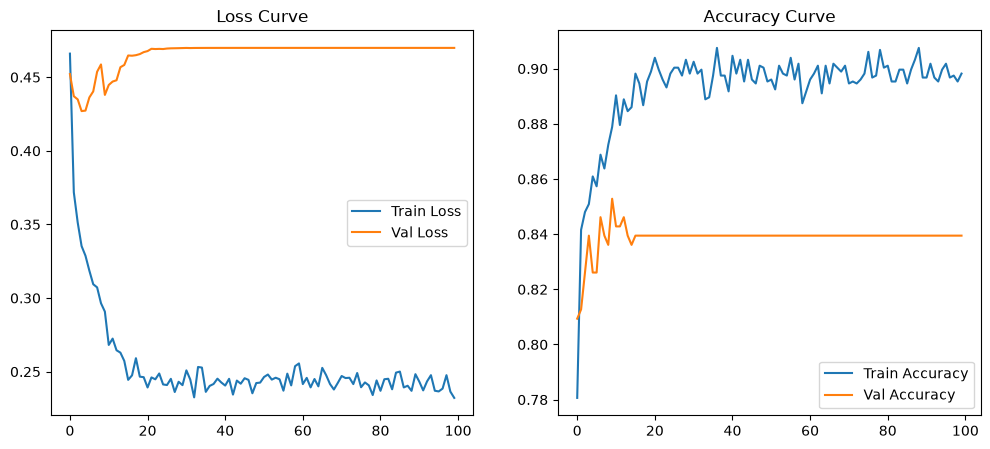

In [36]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Val Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()


In [37]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        out = model(xb)
        preds = torch.argmax(out, dim=1)
        y_true.extend(yb.numpy())
        y_pred.extend(preds.numpy())


In [38]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


Accuracy: 0.822742474916388
Precision: 0.8251509603164161
Recall: 0.822742474916388
F1 Score: 0.8223808262468603

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       150
           1       0.85      0.78      0.81       149

    accuracy                           0.82       299
   macro avg       0.83      0.82      0.82       299
weighted avg       0.83      0.82      0.82       299



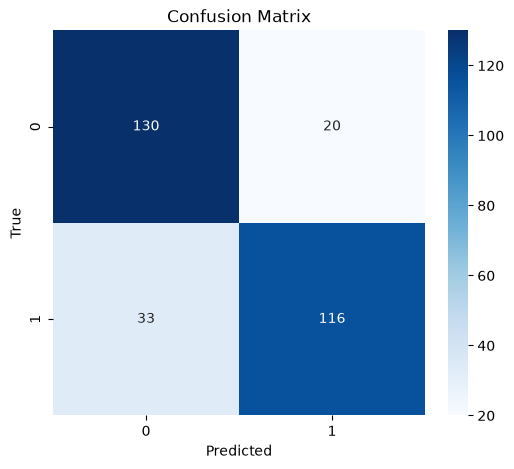

In [39]:
import seaborn as sns
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [40]:
# Save model weights
torch.save(model.state_dict(), "crime_classifier_model.pth")

# Save scaler also (very important!)
import joblib
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")


Model and scaler saved successfully.


In [41]:
# Load scaler
scaler = joblib.load("scaler.pkl")

# Recreate model architecture
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_clf))

model = ClassifierNet(input_dim, num_classes)

# Load saved weights
model.load_state_dict(torch.load("crime_classifier_model.pth"))
model.eval()

print("Model loaded successfully and ready for prediction.")


Model loaded successfully and ready for prediction.


In [42]:
feature_names = X.columns.tolist()
num_features = len(feature_names)

print("Number of input features:", num_features)
print("Feature names:")
for i, f in enumerate(feature_names):
    print(f"{i+1}. {f}")


Number of input features: 100
Feature names:
1. population
2. householdsize
3. racepctblack
4. racePctWhite
5. racePctAsian
6. racePctHisp
7. agePct12t21
8. agePct12t29
9. agePct16t24
10. agePct65up
11. numbUrban
12. pctUrban
13. medIncome
14. pctWWage
15. pctWFarmSelf
16. pctWInvInc
17. pctWSocSec
18. pctWPubAsst
19. pctWRetire
20. medFamInc
21. perCapInc
22. whitePerCap
23. blackPerCap
24. indianPerCap
25. AsianPerCap
26. OtherPerCap
27. HispPerCap
28. NumUnderPov
29. PctPopUnderPov
30. PctLess9thGrade
31. PctNotHSGrad
32. PctBSorMore
33. PctUnemployed
34. PctEmploy
35. PctEmplManu
36. PctEmplProfServ
37. PctOccupManu
38. PctOccupMgmtProf
39. MalePctDivorce
40. MalePctNevMarr
41. FemalePctDiv
42. TotalPctDiv
43. PersPerFam
44. PctFam2Par
45. PctKids2Par
46. PctYoungKids2Par
47. PctTeen2Par
48. PctWorkMomYoungKids
49. PctWorkMom
50. NumIlleg
51. PctIlleg
52. NumImmig
53. PctImmigRecent
54. PctImmigRec5
55. PctImmigRec8
56. PctImmigRec10
57. PctRecentImmig
58. PctRecImmig5
59. PctRecIm

In [43]:
import joblib
joblib.dump(feature_names, "feature_names.pkl")


['feature_names.pkl']

In [44]:
def predict_from_test_row_scaled(model, X_test_tensor, y_test_tensor, row_index):
    """
    Use when X_test is already scaled and converted to tensor
    """

    if row_index < 0 or row_index >= len(X_test_tensor):
        raise ValueError("Row index out of range")

    sample_tensor = X_test_tensor[row_index].unsqueeze(0)

    model.eval()
    with torch.no_grad():
        output = model(sample_tensor)
        predicted_class = torch.argmax(output, dim=1).item()

    true_class = y_test_tensor[row_index].item()

    print(f"Row Index        : {row_index}")
    print(f"Predicted Class : {predicted_class}")
    print(f"True Class      : {true_class}")

    return predicted_class, true_class


In [45]:
predict_from_test_row_scaled(model, X_test, y_test, row_index=10)

Row Index        : 10
Predicted Class : 1
True Class      : 1


(1, 1)

In [50]:
label_map = {
    0: "Low Crime Area",
    1: "High Crime Area"
}

pred, true = predict_from_test_row_scaled(model, X_test, y_test, 10)

print("Predicted:", label_map[pred])
print("Actual   :", label_map[true])

Row Index        : 10
Predicted Class : 1
True Class      : 1
Predicted: High Crime Area
Actual   : High Crime Area


# Can you convert this task for regression problem